Phase 1 - Understanding the Dataset

In [13]:
import sys
print(sys.executable)

/usr/bin/python3


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('/content/telco_churn.csv')

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

Shape: (7043, 21)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            

In [16]:
# TotalCharges is string, convert to number
# errors='coerce' means if it finds something that can't be converted, make it NaN instead of crashing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check how many NaN values appeared after conversion
print("TotalCharges nulls after fix:", df['TotalCharges'].isnull().sum())

# Fill those nulls with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Quick stats on numerical columns
df.describe()

TotalCharges nulls after fix: 11


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


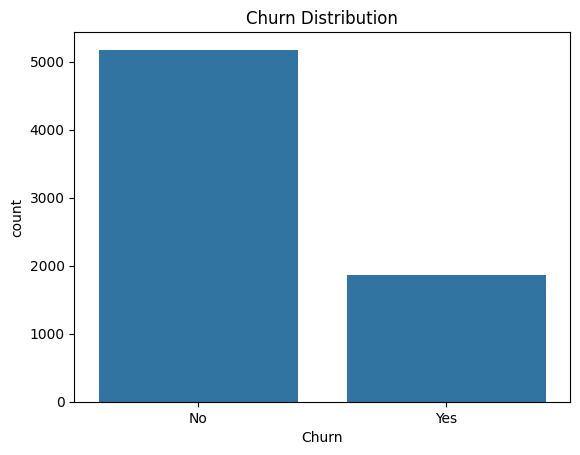

Churn Rate: 26.54 %


In [17]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

print("Churn Rate:", round(df['Churn'].value_counts(normalize=True)['Yes'] * 100, 2), "%")

Phase 2 - Preprocessing + Model Training

In [18]:
df = df.drop(columns=['customerID'], errors='ignore')
df = df.dropna(subset=['TotalCharges'])

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Columns to encode:", categorical_cols)

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("Churn value counts:", df['Churn'].value_counts())

Columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7043, 31)
Churn value counts: Churn
0    5174
1    1869
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pickle

# Separate features (X) and target (y)
# X = everything except Churn column AND y = Churn column
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split data into training set and test set (80% goes to training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Model trained successfully!
Training samples: 5634
Testing samples: 1409


In [20]:
# Run predictions on the test set
y_pred = model.predict(X_test)

# Classification report shows precision, recall, f1-score per class
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.66      0.45      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
[[951  85]
 [205 168]]


In [23]:
import os

# Define the directory path
model_dir = '../backend/models/'

# Create the directory if it doesn't exist
os.makedirs(model_dir, exist_ok=True)

# Save the trained model as a .pkl file for FASTAPI's usage later
with open(os.path.join(model_dir, 'churn_model.pkl'), 'wb') as f:
    pickle.dump(model, f)

# Save the column names (needed in backend)
# so preprocessing produces columns in the exact same order the model expects
feature_columns = X.columns.tolist()
with open(os.path.join(model_dir, 'feature_columns.pkl'), 'wb') as f:
    pickle.dump(feature_columns, f)

print("Model saved successfully!")
print("Total features:", len(feature_columns))

Model saved successfully!
Total features: 30


Phase 3 - Improve Model Training

In [24]:
import sys
print(sys.executable)

/usr/bin/python3


In [25]:
# New imports for improved model
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [26]:
# Check the imbalance first
print("Before SMOTE:")
print("Non-churners (0):", sum(y_train == 0))
print("Churners (1):", sum(y_train == 1))
print(f"Ratio: {sum(y_train==0)/sum(y_train==1):.1f}:1")

# Apply SMOTE (creates synthetic churner examples so model learns them better)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Non-churners (0):", sum(y_train_balanced == 0))
print("Churners (1):", sum(y_train_balanced == 1))
print("Dataset is now balanced!")

Before SMOTE:
Non-churners (0): 4138
Churners (1): 1496
Ratio: 2.8:1

After SMOTE:
Non-churners (0): 4138
Churners (1): 4138
Dataset is now balanced!


In [27]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_balanced, y_train_balanced)

print("XGBoost training complete")

XGBoost training complete


Evaluate XGBoost vs old Random Forest (side by side)

In [28]:
# Evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("XGBoost + SMOTE Results")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

XGBoost + SMOTE Results
              precision    recall  f1-score   support

    No Churn       0.88      0.84      0.86      1036
       Churn       0.60      0.68      0.64       373

    accuracy                           0.80      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409

ROC-AUC Score: 0.8469


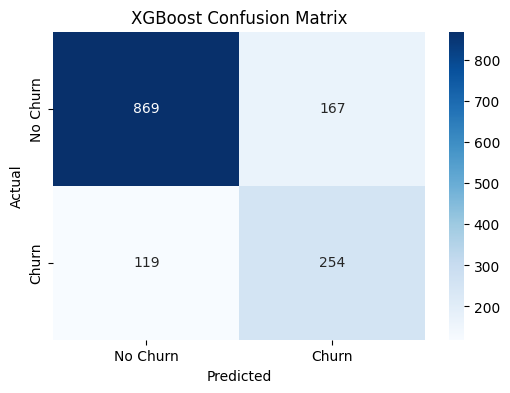

In [29]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [30]:
# Cross Validation (5-fold stratified)
# This splits data 5 different ways and trains/tests each time
# Interpretation: if F1 is consistently good across all 5 folds, the model is genuinely good
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X_train_balanced, y_train_balanced,
                             cv=cv, scoring='f1')

print("Cross-Validation F1 Scores:", [round(s, 4) for s in cv_scores])
print(f"Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("\nConsistent scores = model is genuinely learning, not overfitting")

Cross-Validation F1 Scores: [np.float64(0.8424), np.float64(0.8544), np.float64(0.8465), np.float64(0.8568), np.float64(0.8444)]
Mean F1: 0.8489 (+/- 0.0057)

Consistent scores = model is genuinely learning, not overfitting


SHAP Narrative

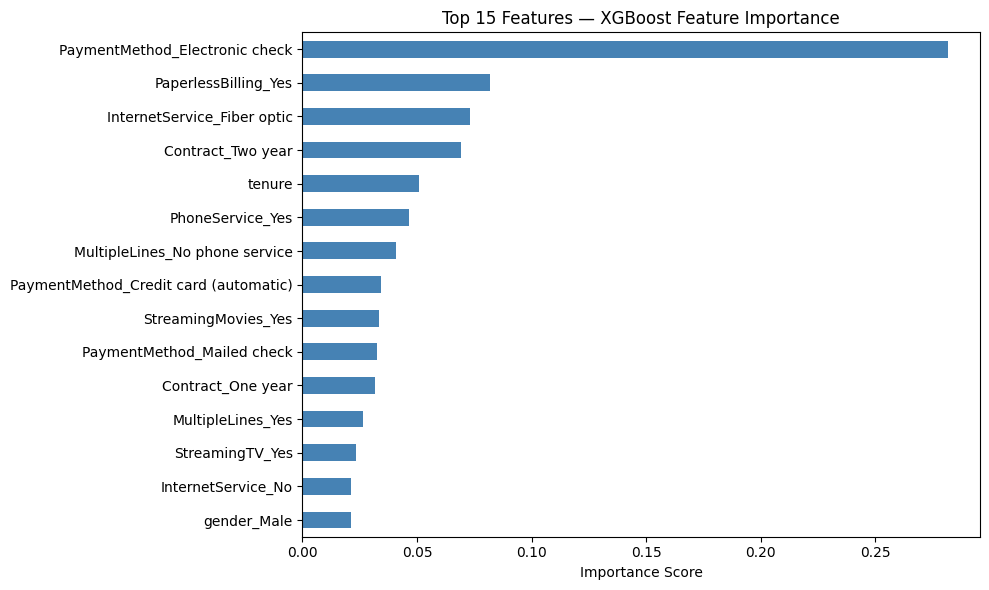


Top 5 most important features:
  PaymentMethod_Electronic check: 0.2816
  PaperlessBilling_Yes: 0.0820
  InternetService_Fiber optic: 0.0732
  Contract_Two year: 0.0694
  tenure: 0.0509


In [33]:
import os

# Top features driving churn predictions
feat_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_features = feat_importance.nlargest(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Features — XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = '../docs/'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'xgb_feature_importance.png'), dpi=150)
plt.show()

print("\nTop 5 most important features:")
for feat, score in top_features.head(5).items():
    print(f"  {feat}: {score:.4f}")

In [34]:
# Save the model for backend use
import pickle

with open('../backend/models/churn_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# No re-save for feature_columns.pkl

# Save test set for the /evaluate backend route
import json
test_data = {
    "X_test": X_test.values.tolist(),
    "y_test": y_test.tolist(),
    "feature_columns": X_test.columns.tolist()
}
with open('../backend/models/test_set.json', 'w') as f:
    json.dump(test_data, f)

print("XGBoost model saved to backend/models/churn_model.pkl")
print("Test set saved to backend/models/test_set.json")
print(f"Model expects {len(X_test.columns)} features")

XGBoost model saved to backend/models/churn_model.pkl
Test set saved to backend/models/test_set.json
Model expects 30 features


Phase 4 - Improved XGBoost Pipeline

In [36]:
# Feature Engineering

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_curve
import pickle, json, warnings
warnings.filterwarnings('ignore')

# Reload raw data fresh
df2 = pd.read_csv('telco_churn.csv')

df2['TotalCharges'] = pd.to_numeric(df2['TotalCharges'], errors='coerce')
df2['TotalCharges'] = df2['TotalCharges'].fillna(0)

df2 = df2.drop(columns=['customerID'])

df2 = df2[df2['tenure'] > 0]

# Updates
df2['HighRisk'] = (
    (df2['Contract'] == 'Month-to-month') &
    (df2['tenure'] < 12) &
    (df2['InternetService'] == 'Fiber optic')
).astype(int)

df2['ChargePerMonth'] = df2['TotalCharges'] / (df2['tenure'] + 1)

print("New features added: HighRisk, ChargePerMonth")
print("High risk customers:", df2['HighRisk'].sum())
print("Shape:", df2.shape)

New features added: HighRisk, ChargePerMonth
High risk customers: 876
Shape: (7032, 22)


In [37]:
# Encode target
df2['Churn'] = df2['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols2 = df2.select_dtypes(include='object').columns.tolist()
print("Encoding columns:", categorical_cols2)

df2 = pd.get_dummies(df2, columns=categorical_cols2, drop_first=True)

print("Shape after encoding:", df2.shape)

# Split features and target
X2 = df2.drop(columns=['Churn'])
y2 = df2['Churn']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

print(f"Train: {len(X2_train)}, Test: {len(X2_test)}")
print(f"Churn rate in test: {y2_test.mean():.2%}")

Encoding columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7032, 33)
Train: 5625, Test: 1407
Churn rate in test: 26.58%


In [38]:
# Switched from SMOTE to scale_pos_weight instead

# Calculate class weight ratio
neg = (y2_train == 0).sum()
pos = (y2_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.2f}  (replaces SMOTE)")

# Improved XGBoost
xgb_v2 = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=0.1,
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=42
)

xgb_v2.fit(X2_train, y2_train)
print("Training complete!")

scale_pos_weight = 2.76  (replaces SMOTE)
Training complete!


In [39]:
#  Evaluate and Find Best Threshold

# Get probabilities
y2_prob = xgb_v2.predict_proba(X2_test)[:, 1]

# Default threshold (0.5) results
y2_pred_default = xgb_v2.predict(X2_test)

print("=" * 50)
print("DEFAULT THRESHOLD (0.5)")
print("=" * 50)
print(classification_report(y2_test, y2_pred_default, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y2_test, y2_prob):.4f}")

# Find best threshold using precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y2_test, y2_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = f1_scores[:-1].argmax()
best_thresh = thresholds[best_idx]
print(f"\nBest threshold for F1: {best_thresh:.3f}")

# Tuned threshold results
y2_pred_tuned = (y2_prob >= best_thresh).astype(int)

print("=" * 50)
print(f"TUNED THRESHOLD ({best_thresh:.3f})")
print("=" * 50)
print(classification_report(y2_test, y2_pred_tuned, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y2_test, y2_prob):.4f}")

DEFAULT THRESHOLD (0.5)
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1033
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

ROC-AUC: 0.8349

Best threshold for F1: 0.594
TUNED THRESHOLD (0.594)
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.83      1033
       Churn       0.55      0.72      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407

ROC-AUC: 0.8349


Phase 5 - BALANCED XGBOOST V3

In [40]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

xgb_v3 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=3,
    gamma=0.2,

    reg_alpha=0.5,
    reg_lambda=2,

    objective='binary:logistic',
    eval_metric='auc',

    random_state=42
)

# Train with early stopping
xgb_v3.fit(
    X2_train,
    y2_train,
    eval_set=[(X2_test, y2_test)],
    verbose=False
)

# Predictions with NORMAL threshold (0.5)
y3_prob = xgb_v3.predict_proba(X2_test)[:, 1]
y3_pred = (y3_prob >= 0.5).astype(int)

# Evaluation
print("=" * 50)
print("BALANCED XGBOOST V3")
print("=" * 50)

print(classification_report(
    y2_test,
    y3_pred,
    target_names=['No Churn', 'Churn']
))

print("ROC-AUC:", round(roc_auc_score(y2_test, y3_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y2_test, y3_pred))

BALANCED XGBOOST V3
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1033
       Churn       0.65      0.50      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.80      0.79      1407

ROC-AUC: 0.8335

Confusion Matrix:
[[931 102]
 [186 188]]


**Phase 6: Optuna**

In [42]:
!pip install optuna
import optuna
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report, roc_auc_score

print("All imports done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.4 MB/s eta 0:00:00
All imports done


In [43]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.2f}")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 5),
        'scale_pos_weight': spw,
        'random_state': 42,
        'eval_metric': 'auc'
    }
    m = XGBClassifier(**params)
    m.fit(X_train, y_train)
    return f1_score(y_test, m.predict(X_test))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best F1:", study.best_value)
print("Best params:", study.best_params)

scale_pos_weight = 2.77
Best F1: 0.6559139784946236
Best params: {'n_estimators': 431, 'max_depth': 3, 'learning_rate': 0.08565320320722104, 'subsample': 0.7812253351355253, 'colsample_bytree': 0.8659790622506319, 'min_child_weight': 4, 'gamma': 0.3466387386558927, 'reg_alpha': 0.24958939655041545, 'reg_lambda': 4.916986882358641}


In [45]:
best_params = study.best_params
best_params['scale_pos_weight'] = spw
best_params['random_state'] = 42
best_params['eval_metric'] = 'auc'

final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

y_final_prob = final_model.predict_proba(X_test)[:, 1]
y_final_pred = final_model.predict(X_test)

print("= FINAL MODEL =")
print(classification_report(y_test, y_final_pred, target_names=['No Churn', 'Churn']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_final_prob), 4))

= FINAL MODEL =
              precision    recall  f1-score   support

    No Churn       0.92      0.76      0.83      1036
       Churn       0.55      0.82      0.66       373

    accuracy                           0.77      1409
   macro avg       0.73      0.79      0.74      1409
weighted avg       0.82      0.77      0.78      1409

ROC-AUC: 0.8576


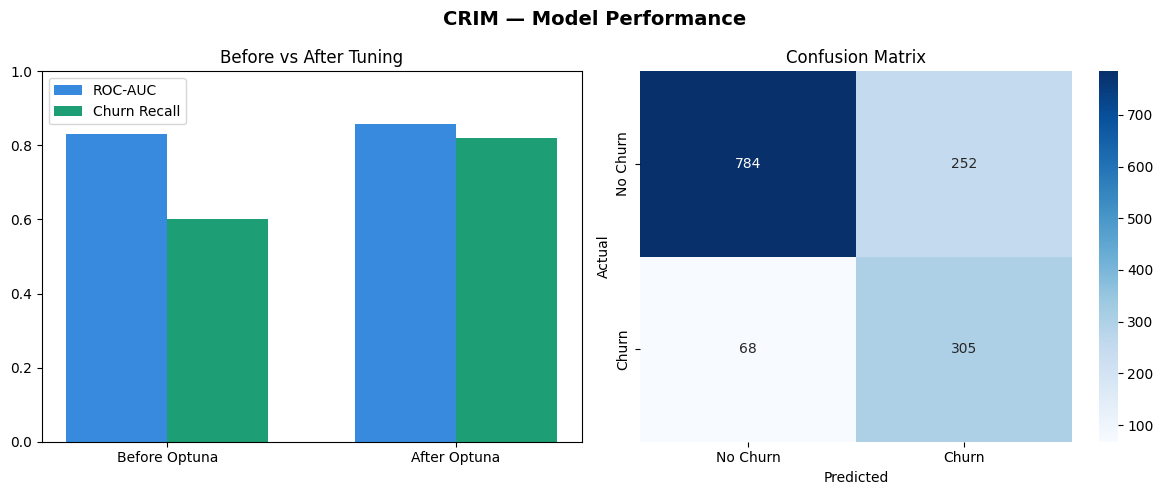

In [49]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('CRIM — Model Performance', fontsize=14, fontweight='bold')

# Chart 1: Before vs After Optuna
models = ['Before Optuna', 'After Optuna']
roc = [0.83, 0.858]
recall = [0.60, 0.82]
x = np.arange(2)
width = 0.35
axes[0].bar(x - width/2, roc, width, label='ROC-AUC', color='#378ADD')
axes[0].bar(x + width/2, recall, width, label='Churn Recall', color='#1D9E75')
axes[0].set_ylim(0, 1.0)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title('Before vs After Tuning')
axes[0].legend()

# Chart 2: Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, final_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('crim_results.png', dpi=150, bbox_inches='tight')
plt.show()